# 🧠 Redes Neuronales - Compuertas Lógicas

**Objetivo:** Implementar dos redes neuronales con **2 capas ocultas** con backpropagation para reconocer compuertas **NAND** y **XOR**.

| Red | Compuerta | Descripción |
|-----|-----------|-------------|
| Red 1 | **NAND** | NOT AND — salida 0 solo cuando ambas entradas son 1 |
| Red 2 | **XOR**  | OR exclusivo — salida 1 cuando las entradas son distintas |

### Arquitectura de cada red
```
Capa de Entrada (2 neuronas)
        ↓
Capa Oculta 1 (4 neuronas)
        ↓
Capa Oculta 2 (4 neuronas)
        ↓
Capa de Salida (1 neurona)
```

## Instalación de dependencias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## Funciones Base

In [2]:
# Funciones de activación
def sig(s):
    """Función sigmoide."""
    return 1 / (1 + np.exp(-s))

def dSig_diag(z):
    """
    Matriz diagonal de derivadas de la sigmoide.
    Recibe z como vector columna (n,1) y devuelve matriz (n,n).
    """
    s = sig(z).flatten()
    return np.diag(s * (1 - s))    # derivada correcta: σ(z)·(1−σ(z))

## 1. Red Neuronal — Compuerta NAND

**Tabla de verdad NAND:**

| A | B | A NAND B |
|---|---|----------|
| 0 | 0 | **1** |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | **0** |

## DataSet para NAND

In [4]:
X_nand = np.array([[0, 0, 1, 1],
                   [0, 1, 0, 1]], dtype=float)

Y_nand = np.array([[1, 1, 1, 0]], dtype=float)   # salidas NAND

print("Dataset NAND")
print("Entradas X:\n", X_nand)
print("Salidas Y :", Y_nand)

Dataset NAND
Entradas X:
 [[0. 0. 1. 1.]
 [0. 1. 0. 1.]]
Salidas Y : [[1. 1. 1. 0.]]


## Pesos para NAND

In [50]:
# Arquitectura:  2 → 4 → 4 → 1
np.random.seed(42)

# Capa 1: (nn_1=4) × (nn_0=2)
W1_nand = np.random.randn(4, 2) * 0.5
b1_nand = np.zeros((4, 1))

# Capa 2: (nn_2=4) × (nn_1=4)
W2_nand = np.random.randn(4, 4) * 0.5
b2_nand = np.zeros((4, 1))

# Capa de salida: (nn_3=1) × (nn_2=4)
W3_nand = np.random.randn(1, 4) * 0.5
b3_nand = np.zeros((1, 1))

print("Pesos inicializados para Red NAND")
print(f"  W1: {W1_nand.shape}, W2: {W2_nand.shape}, W3: {W3_nand.shape}")

Pesos inicializados para Red NAND
  W1: (4, 2), W2: (4, 4), W3: (1, 4)


## Forward Pass y Backpropagation - NAND

In [51]:
def propaga_nand(Xo, W1, b1, W2, b2, W3, b3):
    """Propagación hacia adelante para un ejemplo (columna de Xo)."""
    # Z por pre-activación - A por activación
    Z1 = np.dot(W1, Xo) + b1
    A1 = sig(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sig(Z2)
    Z3 = np.dot(W3, A2) + b3
    A3 = sig(Z3)
    return A3, Z3, A2, Z2, A1, Z1

def backprop_nand(Xo, Yr, A3, Z3, A2, Z2, A1, Z1, W2, W3):
    """Backpropagation para 2 capas ocultas + capa de salida."""
    err    = Yr - A3

    # Capa de salida
    delta3  = np.dot(dSig_diag(Z3), err) # Término de error
    dEdW3   = -np.dot(delta3, A2.T)      # Gradiente de error pesos
    dEdb3   = -delta3                    # Gradiente de error bias

    # Capa oculta 2
    delta2  = np.dot(np.dot(dSig_diag(Z2), W3.T), delta3)
    dEdW2   = -np.dot(delta2, A1.T)
    dEdb2   = -delta2

    # Capa oculta 1
    delta1  = np.dot(np.dot(dSig_diag(Z1), W2.T), delta2)
    dEdW1   = -np.dot(delta1, Xo.T)
    dEdb1   = -delta1

    return dEdW3, dEdb3, dEdW2, dEdb2, dEdW1, dEdb1

## Entrenamiento - NAND

In [53]:
eta        = 0.5       # tasa de aprendizaje
epocas     = 30000
n_ejemplos = X_nand.shape[1]
historial_error_nand = []

# Copiar pesos para no afectar la inicialización guardada
W1n, b1n = W1_nand.copy(), b1_nand.copy()
W2n, b2n = W2_nand.copy(), b2_nand.copy()
W3n, b3n = W3_nand.copy(), b3_nand.copy()

for epoca in range(epocas):
    error_total = 0

    # Iterar sobre cada ejemplo del dataset
    for j in range(n_ejemplos):
        Xo = X_nand[:, j:j+1]   # columna → (2,1)
        Yr = Y_nand[:, j:j+1]   # etiqueta → (1,1)

        # Forward
        A3, Z3, A2, Z2, A1, Z1 = propaga_nand(Xo, W1n, b1n, W2n, b2n, W3n, b3n)

        # Error cuadrático medio del ejemplo
        error_total += 0.5 * np.sum((Yr - A3)**2)

        # Backpropagation
        dEdW3, dEdb3, dEdW2, dEdb2, dEdW1, dEdb1 = backprop_nand(
            Xo, Yr, A3, Z3, A2, Z2, A1, Z1, W2n, W3n)

        # Actualizar pesos
        W3n -= eta * dEdW3;  b3n -= eta * dEdb3
        W2n -= eta * dEdW2;  b2n -= eta * dEdb2
        W1n -= eta * dEdW1;  b1n -= eta * dEdb1

    historial_error_nand.append(error_total / n_ejemplos)

print(f"Entrenamiento NAND finalizado ({epocas} épocas)")
print(f"Error final promedio: {historial_error_nand[-1]:.6f}")

Entrenamiento NAND finalizado (30000 épocas)
Error final promedio: 0.000007


## Resultados — NAND

In [55]:
print("=" * 45)
print("  RESULTADOS DE LA RED NEURONAL — NAND")
print("=" * 45)
print(f"{'A':>4} {'B':>4} | {'Esperado':>9} {'Obtenido':>9} {'Redondeado':>11}")
print("-" * 45)

for j in range(n_ejemplos):
    Xo = X_nand[:, j:j+1]
    Yr = Y_nand[:, j:j+1]
    A3, *_ = propaga_nand(Xo, W1n, b1n, W2n, b2n, W3n, b3n)
    pred = int(np.round(A3[0, 0]))
    ok   = "✅" if pred == int(Yr[0, 0]) else "❌"
    print(f"  {int(Xo[0,0])}   {int(Xo[1,0])}  |  "
          f"{int(Yr[0,0]):>8}   {A3[0,0]:>8.5f}   {pred:>6}  {ok}")

print("=" * 45)

  RESULTADOS DE LA RED NEURONAL — NAND
   A    B |  Esperado  Obtenido  Redondeado
---------------------------------------------
  0   0  |         1    0.99965        1  ✅
  0   1  |         1    0.99644        1  ✅
  1   0  |         1    0.99647        1  ✅
  1   1  |         0    0.00552        0  ✅


## 2. Red Neuronal — Compuerta XOR

**Tabla de verdad XOR:**

| A | B | A XOR B |
|---|---|---------|
| 0 | 0 | **0** |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | **0** |

## DataSet para XOR

In [56]:
X_xor = np.array([[0, 0, 1, 1],
                  [0, 1, 0, 1]], dtype=float)

Y_xor = np.array([[0, 1, 1, 0]], dtype=float)   # salidas XOR

print("Dataset XOR")
print("Entradas X:\n", X_xor)
print("Salidas Y :", Y_xor)

Dataset XOR
Entradas X:
 [[0. 0. 1. 1.]
 [0. 1. 0. 1.]]
Salidas Y : [[0. 1. 1. 0.]]


## Pesos para XOR

In [57]:
# Arquitectura:  2 → 4 → 4 → 1
np.random.seed(33)

W1_xor = np.random.randn(4, 2) * 0.5
b1_xor = np.zeros((4, 1))

W2_xor = np.random.randn(4, 4) * 0.5
b2_xor = np.zeros((4, 1))

W3_xor = np.random.randn(1, 4) * 0.5
b3_xor = np.zeros((1, 1))

print("Pesos inicializados para Red XOR")
print(f"  W1: {W1_xor.shape}, W2: {W2_xor.shape}, W3: {W3_xor.shape}")

Pesos inicializados para Red XOR
  W1: (4, 2), W2: (4, 4), W3: (1, 4)


## Forward Pass y Backpropagation - XOR

In [59]:
#   Misma estructura que NAND; se definen por separado para mayor claridad.

def propaga_xor(Xo, W1, b1, W2, b2, W3, b3):
    Z1 = np.dot(W1, Xo) + b1
    A1 = sig(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sig(Z2)
    Z3 = np.dot(W3, A2) + b3
    A3 = sig(Z3)
    return A3, Z3, A2, Z2, A1, Z1

def backprop_xor(Xo, Yr, A3, Z3, A2, Z2, A1, Z1, W2, W3):
    err    = Yr - A3

    delta3  = np.dot(dSig_diag(Z3), err)
    dEdW3   = -np.dot(delta3, A2.T)
    dEdb3   = -delta3

    delta2  = np.dot(np.dot(dSig_diag(Z2), W3.T), delta3)
    dEdW2   = -np.dot(delta2, A1.T)
    dEdb2   = -delta2

    delta1  = np.dot(np.dot(dSig_diag(Z1), W2.T), delta2)
    dEdW1   = -np.dot(delta1, Xo.T)
    dEdb1   = -delta1

    return dEdW3, dEdb3, dEdW2, dEdb2, dEdW1, dEdb1

## Entrenamiento - XOR

In [61]:
eta        = 0.5      # tasa de aprendizaje
epocas     = 30000
n_ejemplos = X_xor.shape[1]
historial_error_xor = []

W1x, b1x = W1_xor.copy(), b1_xor.copy()
W2x, b2x = W2_xor.copy(), b2_xor.copy()
W3x, b3x = W3_xor.copy(), b3_xor.copy()

for epoca in range(epocas):
    error_total = 0

    for j in range(n_ejemplos):
        Xo = X_xor[:, j:j+1]
        Yr = Y_xor[:, j:j+1]

        # Forward
        A3, Z3, A2, Z2, A1, Z1 = propaga_xor(Xo, W1x, b1x, W2x, b2x, W3x, b3x)

        # Error cuadrático medio del ejemplo
        error_total += 0.5 * np.sum((Yr - A3)**2)

        # BackPropagation
        dEdW3, dEdb3, dEdW2, dEdb2, dEdW1, dEdb1 = backprop_xor(
            Xo, Yr, A3, Z3, A2, Z2, A1, Z1, W2x, W3x)

        # Actualizar pesos
        W3x -= eta * dEdW3;  b3x -= eta * dEdb3
        W2x -= eta * dEdW2;  b2x -= eta * dEdb2
        W1x -= eta * dEdW1;  b1x -= eta * dEdb1

    historial_error_xor.append(error_total / n_ejemplos)

print(f"Entrenamiento XOR finalizado ({epocas} épocas)")
print(f"Error final promedio: {historial_error_xor[-1]:.6f}")

Entrenamiento XOR finalizado (30000 épocas)
Error final promedio: 0.000040


## Resultados — XOR

In [62]:
print("=" * 45)
print("  RESULTADOS DE LA RED NEURONAL — XOR")
print("=" * 45)
print(f"{'A':>4} {'B':>4} | {'Esperado':>9} {'Obtenido':>9} {'Redondeado':>11}")
print("-" * 45)

for j in range(n_ejemplos):
    Xo = X_xor[:, j:j+1]
    Yr = Y_xor[:, j:j+1]
    A3, *_ = propaga_xor(Xo, W1x, b1x, W2x, b2x, W3x, b3x)
    pred = int(np.round(A3[0, 0]))
    ok   = "✅" if pred == int(Yr[0, 0]) else "❌"
    print(f"  {int(Xo[0,0])}   {int(Xo[1,0])}  |  "
          f"{int(Yr[0,0]):>8}   {A3[0,0]:>8.5f}   {pred:>6}  {ok}")

print("=" * 45)

  RESULTADOS DE LA RED NEURONAL — XOR
   A    B |  Esperado  Obtenido  Redondeado
---------------------------------------------
  0   0  |         0    0.00801        0  ✅
  0   1  |         1    0.99142        1  ✅
  1   0  |         1    0.99153        1  ✅
  1   1  |         0    0.01046        0  ✅


## Visualización de la Curva de Error

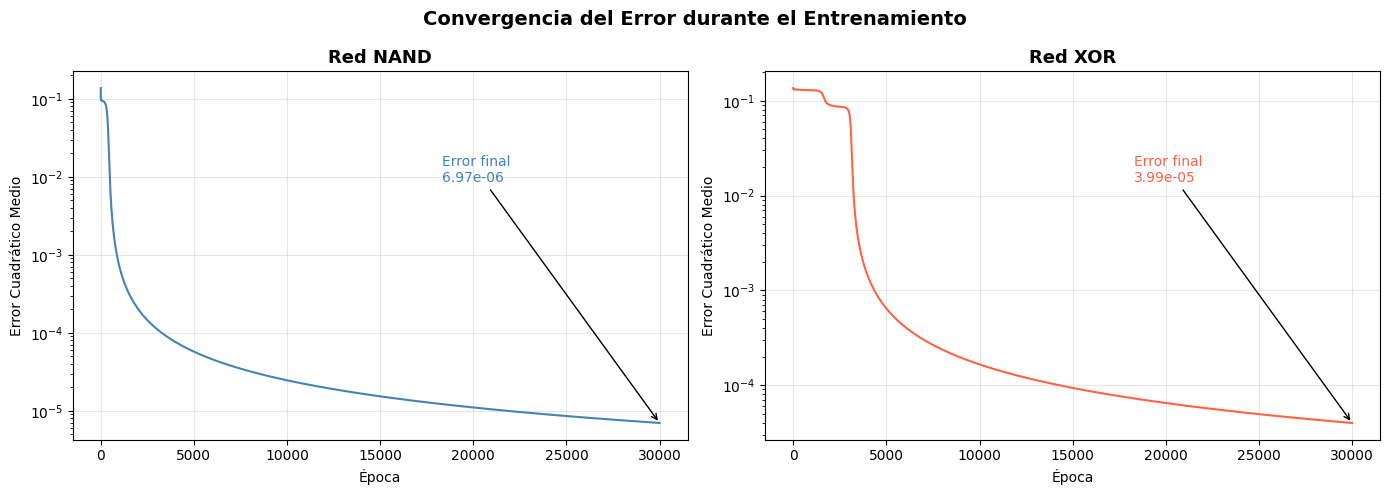

In [63]:
# ── Gráficas de convergencia ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Convergencia del Error durante el Entrenamiento", fontsize=14, fontweight="bold")

# --- NAND ---
ax = axes[0]
ax.plot(historial_error_nand, color="steelblue", linewidth=1.5)
ax.set_title("Red NAND", fontsize=13, fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("Error Cuadrático Medio")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.annotate(f"Error final\n{historial_error_nand[-1]:.2e}",
            xy=(len(historial_error_nand)-1, historial_error_nand[-1]),
            xytext=(0.6, 0.7), textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='steelblue')

# --- XOR ---
ax = axes[1]
ax.plot(historial_error_xor, color="tomato", linewidth=1.5)
ax.set_title("Red XOR", fontsize=13, fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("Error Cuadrático Medio")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.annotate(f"Error final\n{historial_error_xor[-1]:.2e}",
            xy=(len(historial_error_xor)-1, historial_error_xor[-1]),
            xytext=(0.6, 0.7), textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='tomato')

plt.tight_layout()
plt.show()

## Visualización de la Región de Decisión

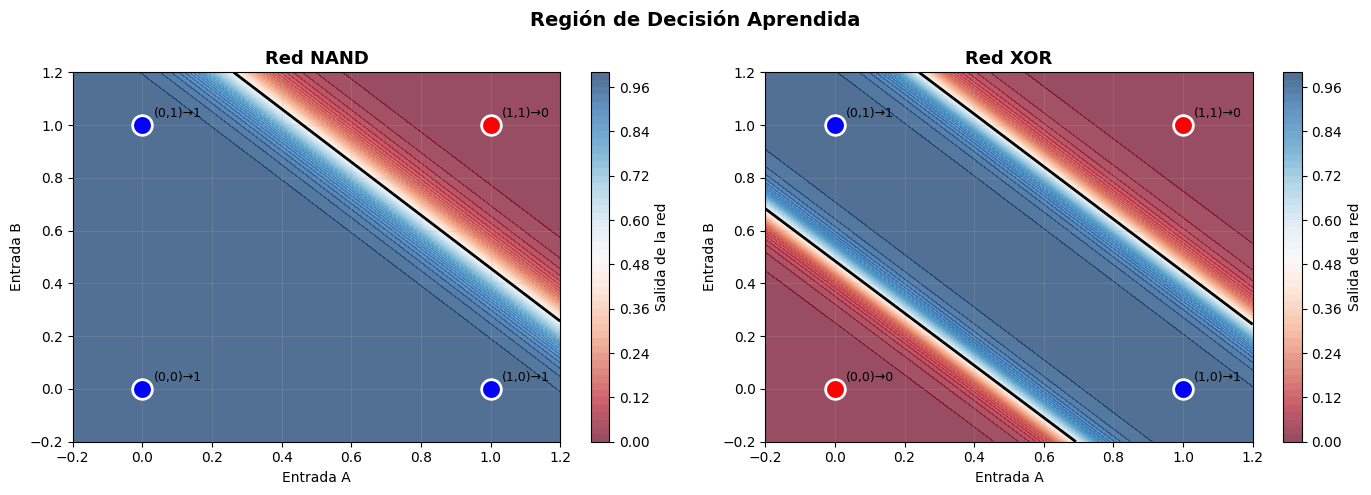

Azul = salida 1  |  Rojo = salida 0  |  Línea negra = frontera de decisión (0.5)


In [64]:
# ── Superficie de decisión (malla 100×100) ───────────────────────────────────
res   = 200
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, res),
                     np.linspace(-0.2, 1.2, res))
grid  = np.c_[xx.ravel(), yy.ravel()].T   # shape (2, res²)

# Predecir NAND para cada punto de la malla
Z_nand = np.zeros(grid.shape[1])
for k in range(grid.shape[1]):
    xk = grid[:, k:k+1]
    A3, *_ = propaga_nand(xk, W1n, b1n, W2n, b2n, W3n, b3n)
    Z_nand[k] = A3[0, 0]
Z_nand = Z_nand.reshape(xx.shape)

# Predecir XOR para cada punto de la malla
Z_xor = np.zeros(grid.shape[1])
for k in range(grid.shape[1]):
    xk = grid[:, k:k+1]
    A3, *_ = propaga_xor(xk, W1x, b1x, W2x, b2x, W3x, b3x)
    Z_xor[k] = A3[0, 0]
Z_xor = Z_xor.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Región de Decisión Aprendida", fontsize=14, fontweight="bold")

colores_puntos = {0: 'red', 1: 'blue'}

for ax, Z, X_data, Y_data, titulo, cmap in [
    (axes[0], Z_nand, X_nand, Y_nand, "Red NAND", "RdBu"),
    (axes[1], Z_xor,  X_xor,  Y_xor,  "Red XOR",  "RdBu")
]:
    cf = ax.contourf(xx, yy, Z, levels=50, cmap=cmap, alpha=0.7)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    plt.colorbar(cf, ax=ax, label="Salida de la red")

    for j in range(X_data.shape[1]):
        color = 'blue' if Y_data[0, j] == 1 else 'red'
        etiq  = f"({int(X_data[0,j])},{int(X_data[1,j])})→{int(Y_data[0,j])}"
        ax.scatter(X_data[0, j], X_data[1, j], c=color, s=200,
                   edgecolors='white', linewidths=2, zorder=5)
        ax.annotate(etiq, (X_data[0, j], X_data[1, j]),
                    textcoords="offset points", xytext=(8, 6), fontsize=9)

    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.set_xlabel("Entrada A")
    ax.set_ylabel("Entrada B")
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
print("Azul = salida 1  |  Rojo = salida 0  |  Línea negra = frontera de decisión (0.5)")

## Conclusiones y Aprendizajes

Este ejercicio práctico con las compuertas lógicas NAND y XOR nos ha permitido entender y visualizar aspectos fundamentales de las redes neuronales y el algoritmo de **Backpropagation**.

**Observaciones Clave:**

1.  **Potencia de las Redes Neuronales:** Incluso con una arquitectura relativamente simple (2 capas ocultas de 4 neuronas), las redes lograron aprender la lógica de XOR y NAND, demostrando su capacidad para modelar relaciones no lineales entre entradas y salidas.

2.  **Importancia del Backpropagation:** El algoritmo de backpropagation es el corazón del entrenamiento. Permite a la red ajustar de manera eficiente sus pesos y sesgos (`W` y `b`) al propagar el error de la salida hacia atrás a través de las capas. Sin este mecanismo de ajuste iterativo, la red no podría aprender.

3.  **Convergencia del Error:** Las gráficas de error a lo largo de las épocas muestran una disminución constante, indicando que las redes estaban aprendiendo y que el algoritmo de backpropagation funcionó correctamente para minimizar la función de costo (Por supuesto, con cada iteración, aprender es más difícil).

4.  **Regiones de Decisión:** Para NAND, se observa una región de salida alta que abarca la mayoría del espacio, con una caída solo en (1,1). Para XOR, la frontera de decisión es no lineal, separando los puntos (0,1) y (1,0) de los (0,0) y (1,1). Esto valida que la red, a través de sus capas ocultas, puede capturar estas separaciones más complejas.

5.  **Sensibilidad a la Inicialización y Tasa de Aprendizaje:** La inicialización aleatoria de los pesos (`np.random.seed()`) y la elección de la tasa de aprendizaje (`eta`) son factores críticos que podrían influir significativamente en la velocidad y el éxito de la convergencia. Variaciones en `np.random.seed()` resultaron en diferentes valores finales de error, destacando su impacto.